In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

daily_returns = pd.read_csv("../data/processed/daily_returns.csv", index_col=0, parse_dates=True)

tickers = daily_returns.columns.tolist()
n_assets = len(tickers)

trading_days = 252
risk_free_rate = 0.02

In [3]:
def portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate=0.02):
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    return portfolio_return, portfolio_volatility, sharpe_ratio

def minimum_variance_weights(returns_window):
    mean_returns = returns_window.mean() * trading_days
    cov_matrix = returns_window.cov() * trading_days
    
    n_assets = returns_window.shape[1]
    initial_weights = np.array([1 / n_assets] * n_assets)
    bounds = tuple((0, 1) for _ in range(n_assets))
    constraints = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}
    
    def portfolio_volatility(weights):
        return portfolio_performance(weights, mean_returns, cov_matrix)[1]
    
    result = minimize(
        portfolio_volatility,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x

def maximum_sharpe_weights(returns_window):
    mean_returns = returns_window.mean() * trading_days
    cov_matrix = returns_window.cov() * trading_days
    
    n_assets = returns_window.shape[1]
    initial_weights = np.array([1 / n_assets] * n_assets)
    bounds = tuple((0, 1) for _ in range(n_assets))
    constraints = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}
    
    def negative_sharpe(weights):
        return -portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate)[2]
    
    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x

def risk_contribution(weights, cov_matrix):
    portfolio_var = np.dot(weights.T, np.dot(cov_matrix, weights))
    marginal_contrib = np.dot(cov_matrix, weights)
    risk_contrib = weights * marginal_contrib / portfolio_var
    return risk_contrib

def risk_parity_weights(returns_window):
    cov_matrix = returns_window.cov() * trading_days
    
    n_assets = returns_window.shape[1]
    initial_weights = np.array([1 / n_assets] * n_assets)
    bounds = tuple((0, 1) for _ in range(n_assets))
    constraints = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}
    
    def risk_parity_objective(weights):
        rc = risk_contribution(weights, cov_matrix)
        target_rc = np.array([1 / n_assets] * n_assets)
        return np.sum((rc - target_rc) ** 2)
    
    result = minimize(
        risk_parity_objective,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x

In [4]:
def rolling_backtest_with_costs(daily_returns, lookback_window=252, rebalance_window=21, cost_rate=0.001):
    gross_returns = {
        "Equal Weight": [],
        "Minimum Variance": [],
        "Maximum Sharpe": [],
        "Risk Parity": [],
        "SPY Benchmark": []
    }
    
    net_returns = {
        "Equal Weight": [],
        "Minimum Variance": [],
        "Maximum Sharpe": [],
        "Risk Parity": [],
        "SPY Benchmark": []
    }
    
    turnover_history = {
        "Equal Weight": [],
        "Minimum Variance": [],
        "Maximum Sharpe": [],
        "Risk Parity": []
    }
    
    current_weights = {
        "Equal Weight": None,
        "Minimum Variance": None,
        "Maximum Sharpe": None,
        "Risk Parity": None
    }
    
    dates = []
    
    for start in range(lookback_window, len(daily_returns) - rebalance_window, rebalance_window):
        train_window = daily_returns.iloc[start - lookback_window:start]
        test_window = daily_returns.iloc[start:start + rebalance_window]
        
        target_weights = {
            "Equal Weight": np.array([1 / n_assets] * n_assets),
            "Minimum Variance": minimum_variance_weights(train_window),
            "Maximum Sharpe": maximum_sharpe_weights(train_window),
            "Risk Parity": risk_parity_weights(train_window)
        }
        
        for strategy, weights in target_weights.items():
            strategy_gross_returns = test_window.dot(weights)
            
            if current_weights[strategy] is None:
                turnover = 0
            else:
                turnover = np.sum(np.abs(weights - current_weights[strategy]))
            
            transaction_cost = turnover * cost_rate
            
            strategy_net_returns = strategy_gross_returns.copy()
            strategy_net_returns.iloc[0] = strategy_net_returns.iloc[0] - transaction_cost
            
            gross_returns[strategy].extend(strategy_gross_returns.tolist())
            net_returns[strategy].extend(strategy_net_returns.tolist())
            turnover_history[strategy].append(turnover)
            
            current_weights[strategy] = drift_weights(weights, test_window)
        
        gross_returns["SPY Benchmark"].extend(test_window["SPY"].tolist())
        net_returns["SPY Benchmark"].extend(test_window["SPY"].tolist())
        
        dates.extend(test_window.index.tolist())
    
    gross_returns = pd.DataFrame(gross_returns, index=dates)
    net_returns = pd.DataFrame(net_returns, index=dates)
    turnover_history = pd.DataFrame(turnover_history)
    
    return gross_returns, net_returns, turnover_history

In [6]:
def drift_weights(weights, returns_window):
    asset_growth = (1 + returns_window).prod()
    drifted_weights = weights * asset_growth
    drifted_weights = drifted_weights / drifted_weights.sum()
    return drifted_weights

In [7]:
gross_returns, net_returns, turnover_history = rolling_backtest_with_costs(
    daily_returns,
    lookback_window=252,
    rebalance_window=21,
    cost_rate=0.001
)

net_returns.head()

,Equal Weight,Minimum Variance,Maximum Sharpe,Risk Parity,SPY Benchmark
2016-01-05,0.002666,-0.000240,-0.001736,0.001293,0.001691
2016-01-06,-0.004106,0.002448,-0.009611,0.000425,-0.012614
2016-01-07,-0.015195,-0.006126,-0.031331,-0.009636,-0.023992
2016-01-08,-0.008812,-0.004806,-0.008110,-0.006158,-0.010977
2016-01-11,-0.001462,-0.006157,0.003078,-0.003878,0.000990


In [8]:
gross_returns.shape, net_returns.shape, turnover_history.shape

((2499, 5), (2499, 5), (119, 4))

In [9]:
gross_returns.to_csv("../data/processed/backtest_returns_gross.csv")
net_returns.to_csv("../data/processed/backtest_returns_net.csv")
turnover_history.to_csv("../data/processed/turnover_history.csv")

In [10]:
def performance_table(returns, risk_free_rate=0.02):
    table = pd.DataFrame({
        "Annualized Return": returns.mean() * 252,
        "Annualized Volatility": returns.std() * np.sqrt(252),
        "Sharpe Ratio": (returns.mean() * 252 - risk_free_rate) / (returns.std() * np.sqrt(252))
    })
    return table.T

gross_performance = performance_table(gross_returns, risk_free_rate)
net_performance = performance_table(net_returns, risk_free_rate)

gross_performance

,Equal Weight,Minimum Variance,Maximum Sharpe,Risk Parity,SPY Benchmark
Annualized Return,0.097016,0.071141,0.091178,0.093681,0.140472
Annualized Volatility,0.134932,0.098525,0.152204,0.113890,0.181049
Sharpe Ratio,0.570779,0.519069,0.467649,0.646951,0.665409


In [11]:
net_performance

,Equal Weight,Minimum Variance,Maximum Sharpe,Risk Parity,SPY Benchmark
Annualized Return,0.096706,0.069816,0.085233,0.092726,0.140472
Annualized Volatility,0.134932,0.098536,0.152170,0.113899,0.181049
Sharpe Ratio,0.568476,0.505561,0.428686,0.638514,0.665409


In [12]:
gross_performance.to_csv("../data/processed/gross_performance_with_cost_model.csv")
net_performance.to_csv("../data/processed/net_performance_after_transaction_costs.csv")

In [13]:
average_turnover = turnover_history.mean().sort_values(ascending=False)
average_turnover

Maximum Sharpe      0.495406
Minimum Variance    0.110452
Risk Parity         0.079607
Equal Weight        0.025856
dtype: float64

In [14]:
average_turnover.to_csv("../data/processed/average_turnover.csv")

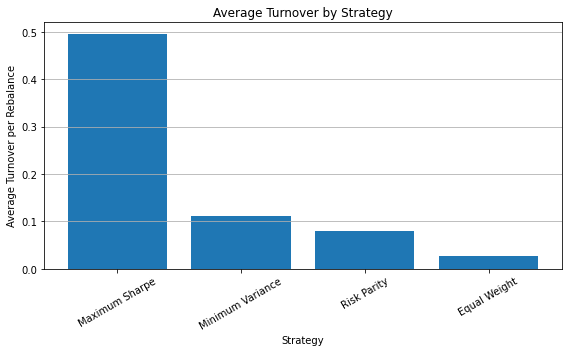

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    average_turnover.index,
    average_turnover.values
)

plt.title("Average Turnover by Strategy")
plt.xlabel("Strategy")
plt.ylabel("Average Turnover per Rebalance")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.tight_layout()

plt.savefig("../figures/average_turnover_by_strategy.png", dpi=300)
plt.show()

## Transaction Cost and Turnover Interpretation

After incorporating a transaction cost model, the optimized strategies experienced lower net returns compared with their gross returns. The maximum Sharpe strategy was the most affected, suggesting that it is more sensitive to rebalancing and estimation changes. In contrast, the equal weight and risk parity strategies were less affected by transaction costs, indicating more stable allocation behavior.

The SPY benchmark remains unchanged because it is treated as a buy-and-hold benchmark without periodic rebalancing costs. This comparison shows that transaction costs can materially affect the practical performance of optimized portfolios, especially strategies with higher turnover.

## Turnover Analysis

The turnover analysis shows that the maximum Sharpe strategy has the highest average turnover, at approximately 49.5% per rebalance. This indicates that the strategy is highly sensitive to changes in estimated expected returns and covariance inputs. As a result, its net performance declines more noticeably after transaction costs are applied.

By contrast, the risk parity and equal weight strategies have much lower turnover, suggesting more stable allocation behavior. This helps explain why their net performance is less affected by transaction costs. The turnover results highlight that a portfolio strategy should not be evaluated only by gross returns; implementation costs and rebalancing stability are also important for practical performance.